Place for examples of capabilities. The following cell is the most reliable way I've found to accomplish the desired behavior, but it might be overkill.

In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\camde\.julia\dev\HybridDynamics.jl`
Precompiling packages...
   1134.5 ms  ✓ HybridDynamics
  1 dependency successfully precompiled in 1 seconds. 21 already precompiled.


In [2]:
using Revise
import HybridDynamics as HD

In [3]:
using LaTeXStrings
import Plots as plt

In [4]:
init = [1.,0.];
tspan = (0., 5.);

function M(q)
    [1.0;;]
end

function V(q)
    q[1]^2
end

# Table/guard
g(q) = q[1]

Lsys = HD.LagSys(M, V; guard = g)

probl = HD.prob(Lsys, init, tspan)
sl = HD.solve(probl)


HybridDynamics.LHSol{Vector{Float64}, Vector{Vector{Float64}}, Vector{Vector{Float64}}, HybridDynamics.prob{HybridDynamics.LagSys{typeof(M), typeof(V), typeof(g), HybridDynamics.var"#13#14"{typeof(g)}, HybridDynamics.var"#LagSys##2#LagSys##3", Float64}, Vector{Float64}, Tuple{Float64, Float64}}, Vector{Float64}, Vector{Float64}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.11000000000000001, 0.2, 0.37, 0.7, 1.1009104369029872, 1.1009104369029872, 2.079893063904489, 2.079893063904489, 3.789786127808978, 5.289313709496454, 5.289313709496454], [[1.0, 0.0], [0.9998000066661009, -0.01999800008948317], [0.999400093325746, -0.03998800124554792], [0.9988003799429394, -0.05996600706762061], [0.9980010264177027, -0.07992802435342126], [0.9970022325461088, -0.09987006389696437], [0.995804237972343, -0.1197881412856009], [0.9848549244155373, -0.21852128295700596], [0.9494354812834569, -0.39083073304780513], [0.8305548427371359, -0.6819816870401603], [0.45516736231871163, -1.02832528

In [5]:
length(sl.t)

18

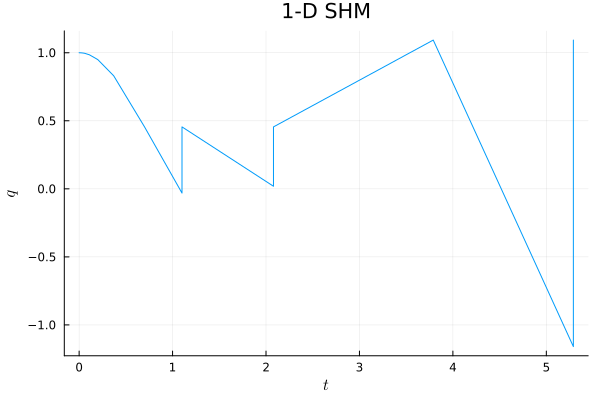

print device already activated


In [10]:
q_vals = getindex.(sl.x, 1)

pl2 = plt.plot(sl.t, q_vals,
    title = "1-D SHM",
    xlabel = L"t",
    ylabel = L"q",
    label = ""
)

display(pl2)